# Inicializando os dados

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import matplotlib.pyplot as plt
import os

from torchvision.datasets import CIFAR10

In [3]:
DATA_DIR = '/content/drive/MyDrive/datasets/cifar10'
CATEGORIES = ['aviao', 'automovel', 'passaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao']

In [4]:
cifar10_train = CIFAR10(DATA_DIR, train = True, download=True)
cifar10_test = CIFAR10(DATA_DIR, train = False, download= True)

In [5]:
(len(cifar10_train)), (len(cifar10_test))

(50000, 10000)

In [6]:
def lookat_dataset(dataset, isTensor = False):
  figure = plt.figure(figsize=(8,8))
  rows,cols = 2,2
  for i in range(1,5):
    sample_idx = torch.randint(len(dataset), size=(1, )).item()
    img, label = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(CATEGORIES[label])
    plt.axis("off")
    if isTensor:
      plt.imshow(img.squeeze().permute(1,2,0))
    else:
      plt.imshow(img)
  plt.show

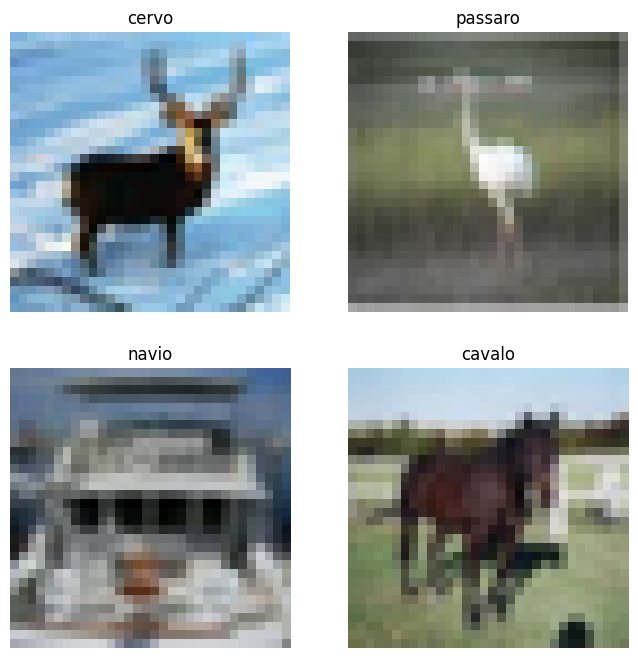

In [7]:
lookat_dataset(cifar10_train)

# Pré-processamento dos dados

In [8]:
import torchvision.transforms as T

In [9]:
from ast import Dict
prep_transform = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(
            (0.4914, 0.4822, 0.4465),
            (0.2470, 0.2435, 0.2616)
        )
    ]
)

tensor_train = CIFAR10(DATA_DIR, train=True, download=False, transform = prep_transform)
tensor_test = CIFAR10(DATA_DIR, train=False, download=False, transform= prep_transform)



In [10]:
imgs = torch.stack([img_t for img_t, _ in tensor_train], dim = 3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [11]:
imgs.view(3, -1).mean(dim = 1)

tensor([-1.2762e-06, -1.7074e-04,  1.1819e-04])

In [12]:
imgs.view(3, -1).std(dim = 1)

tensor([1.0001, 0.9999, 1.0000])

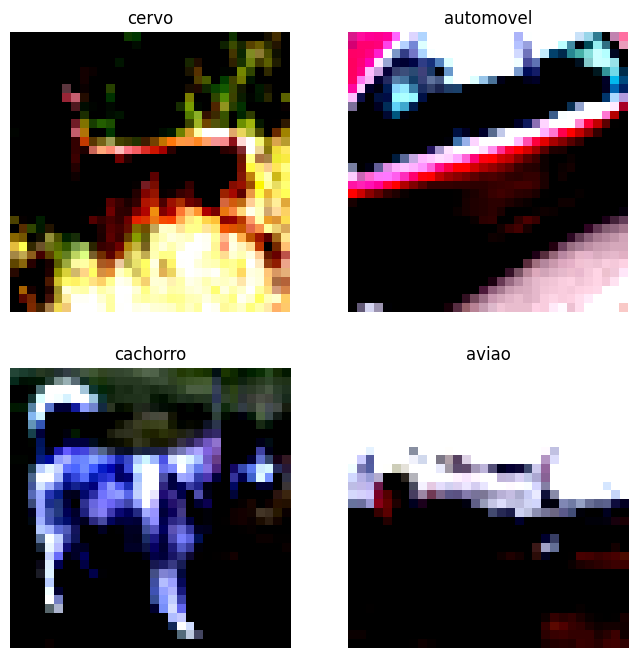

In [13]:
lookat_dataset(tensor_train, True)

# Criando DataLoaders

In [14]:
from torch.utils.data import DataLoader

In [15]:
batch_size =  64
train_loader = DataLoader(tensor_train, batch_size = batch_size, shuffle= True)
test_loader = DataLoader(tensor_test, batch_size= batch_size, shuffle=False)

# Construindo MLP - MultiLayer Perceptron

In [16]:
from torch import nn

In [17]:
class MLPClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.flatten = nn.Flatten() #planifica a matriz (a imagem) - cria um vetor com todos os dados da imagem

    self.layers = nn.Sequential(
        nn.Linear(32*32*3, 256),#pois estamos lidando com imagens 32x32 e como cada imagem possui 3 cores (rgb) temos mais três informações para cada pixel
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,10) #como temos dez classes de objetos temos que no final receber um "vetor" de tamanho 10 com a probabilidade de ser cada tipo de objeto

    )

  def forward(self,image):
    v = self.flatten(image)
    return self.layers(v)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Rodando em {device}')

Rodando em cuda


In [19]:
model = MLPClassifier().to(device)

## Escolhendo Hiperparâmetros

In [20]:
optimizer = torch.optim.SGD(model.parameters(), lr =0.001)
loss_func = nn.CrossEntropyLoss()


In [21]:
def train(model, dataloader, loss_func, optimizer):
  model.train()
  cumloss = 0.0

  for imgs, labels in dataloader:
    imgs, labels = imgs.to(device), labels.to(device)
    pred = model(imgs)

    loss = loss_func(pred, labels)
    #zera os gradientes acumulados
    optimizer.zero_grad()
    #computa os gradientes
    loss.backward()
    # anda no sentido de diminuir o gradiente, ou seja, reduz o erro local
    optimizer.step()

    cumloss += loss.item()

  return cumloss/len(dataloader)

def validate(model, dataloader, lossfunc):
  model.eval()
  cumloss = 0.0

  with torch.no_grad():
    for imgs, labels in dataloader:
      imgs, labels = imgs.to(device), labels.to(device)
      pred = model(imgs)
      loss = loss_func(pred, labels)
      cumloss += loss.item()

  return cumloss/len(dataloader)



In [22]:
def plot_losses(losses):
  fig = plt.figure(figsize = (13,5))
  ax = fig.gca()

  for loss_name, loss_values in losses.items():
    ax.plot(loss_values, label = loss_name)
  ax.legend(fontsize="16")
  ax.set_xlabel("Interation", fontsize='16')
  ax.set_ylabel("Loss", fontsize = '16')
  ax.set_title("Loss vs Iteration", fontsize = '16')

In [23]:
epochs = 41
train_losses = []
test_losses = []
for t in range(epochs):
  train_loss = train(model, train_loader, loss_func, optimizer)
  train_losses.append(train_loss)
  if t % 10 == 0:
    print(f'Epoca: {t} Train Loss: {train_loss}')
  test_loss = validate(model, test_loader, loss_func)
  test_losses.append(test_loss)

Epoca: 0 Train Loss: 2.3092598905953605
Epoca: 10 Train Loss: 2.2950849380639506
Epoca: 20 Train Loss: 2.159142454566858
Epoca: 30 Train Loss: 2.0133927145882335
Epoca: 40 Train Loss: 1.8866300392333808


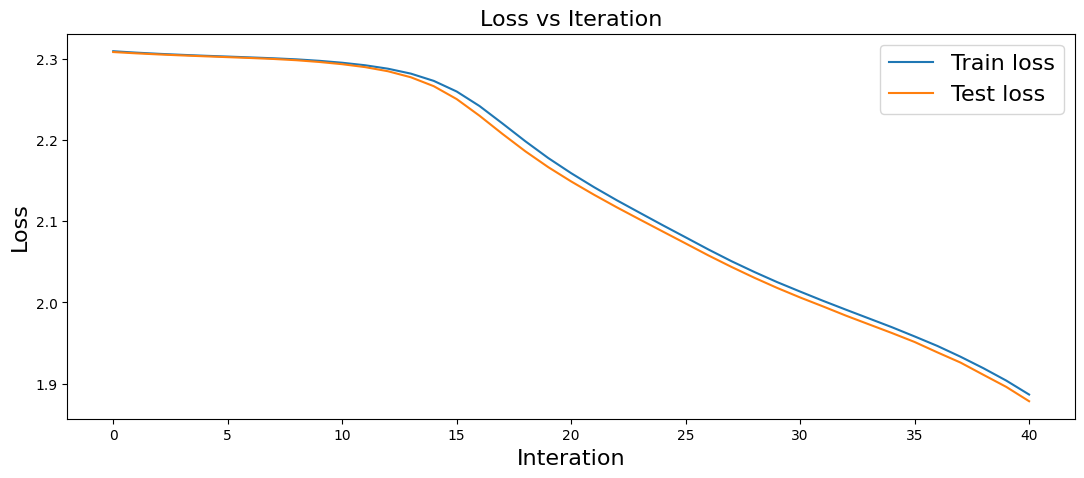

In [24]:
losses = {"Train loss": train_losses, "Test loss": test_losses}
plot_losses(losses)

# Criando nossa Rede de Convolução

In [25]:
class ConvolutionalModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.convlayers = nn.Sequential( #aprende a fazer a representação da imagem
        #padding diz sobre as bordas, ou seja, se iremos aplicar a matriz do kernel apenas sobre a matriz ou se iremos expandir a matriz dos dados da imagem
        # strive diz sobre o quanto que iremos andar sobre a matriz dos dados, por padrão o stride é 1, ou seja, a matriz do kernel é deslocada em 1 sobre a matriz dos dados da imagem
        nn.Conv2d(3, 16, kernel_size=(3,3)), #3 pq são 3 canais de cores e 16 mapas são gerados
        nn.ReLU(),
        nn.MaxPool2d(2,2),
        nn.Conv2d(16,32,kernel_size=(3,3)),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.linearlayer = nn.Sequential( #aprende a classificar a imagem
        nn.Linear(1152,256),
        nn.ReLU(),
        nn.Linear(256,10) #10 classes de imagens
    )

  def forward(self,x):
    x = self.convlayers(x) #aprende as features
    x = torch.flatten(x,1)
    return self.linearlayer(x)

In [26]:
convmodel = ConvolutionalModel().to(device)

In [27]:
conv_optimizer = torch.optim.SGD(convmodel.parameters(), lr = 0.001)
convlossfunc = nn.CrossEntropyLoss()

In [28]:
epochs = 71
conv_train_losses = []
conv_test_losses = []
for t in range(epochs):
  train_loss = train(convmodel, train_loader, convlossfunc, conv_optimizer)
  conv_train_losses.append(train_loss)
  if t % 10 == 0:
    print(f'Epoca: {t} Train Loss: {train_loss}')
  test_loss = validate(convmodel, test_loader, convlossfunc)
  conv_test_losses.append(test_loss)

Epoca: 0 Train Loss: 2.289831636202
Epoca: 10 Train Loss: 1.6607235138068723
Epoca: 20 Train Loss: 1.4203003847690494
Epoca: 30 Train Loss: 1.3107713046281233
Epoca: 40 Train Loss: 1.2138404778354919
Epoca: 50 Train Loss: 1.1254876384039973
Epoca: 60 Train Loss: 1.0505100479516227
Epoca: 70 Train Loss: 0.9837098308383961


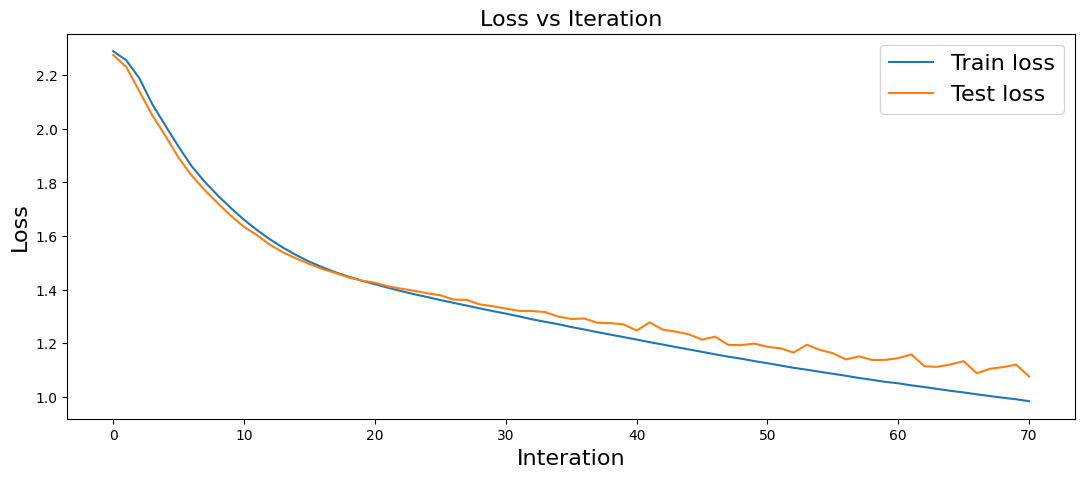

In [29]:
convlosses = {"Train loss": conv_train_losses, "Test loss": conv_test_losses}
plot_losses(convlosses)

In [30]:
def make_confusion_matrix(model, loader, n_classes):
  confusion_matrix = torch.zeros(n_classes, n_classes, dtype=torch.int64)
  with torch.no_grad():
    for i, (imgs, labels) in enumerate(loader):
      imgs = imgs.to(device)
      labels = labels.to(device)
      outputs = model(imgs)
      _, predicted = torch.max(outputs, 1)
      for t, p in zip(torch.as_tensor(labels, dtype=torch.int64).view(-1),
                      torch.as_tensor(predicted, dtype=torch.int64).view(-1)):
        confusion_matrix[t, p] += 1
  return confusion_matrix

def evaluate_accuracy(model, dataloader, classes, verbose=True):
  # prepare to count predictions for each class
  correct_pred = {classname: 0 for classname in classes}
  total_pred = {classname: 0 for classname in classes}

  confusion_matrix = make_confusion_matrix(model, dataloader, len(classes))
  if verbose:
    total_correct = 0.0
    total_prediction = 0.0
    for i, classname in enumerate(classes):
      correct_count = confusion_matrix[i][i].item()
      class_pred = torch.sum(confusion_matrix[i]).item()

      total_correct += correct_count
      total_prediction += class_pred

      accuracy = 100 * float(correct_count) / class_pred
      print("Accuracy for class {:5s} is: {:.1f} %".format(classname,
                                                    accuracy))
  print("Global acccuracy is {:.1f}".format(100 * total_correct/total_prediction))
  return confusion_matrix

In [31]:
conv_confusion_matrix = evaluate_accuracy(convmodel,test_loader,CATEGORIES)

Accuracy for class aviao is: 63.4 %
Accuracy for class automovel is: 74.0 %
Accuracy for class passaro is: 39.6 %
Accuracy for class gato  is: 51.7 %
Accuracy for class cervo is: 64.1 %
Accuracy for class cachorro is: 46.1 %
Accuracy for class sapo  is: 70.5 %
Accuracy for class cavalo is: 69.8 %
Accuracy for class navio is: 80.4 %
Accuracy for class caminhao is: 65.6 %
Global acccuracy is 62.5


<Axes: >

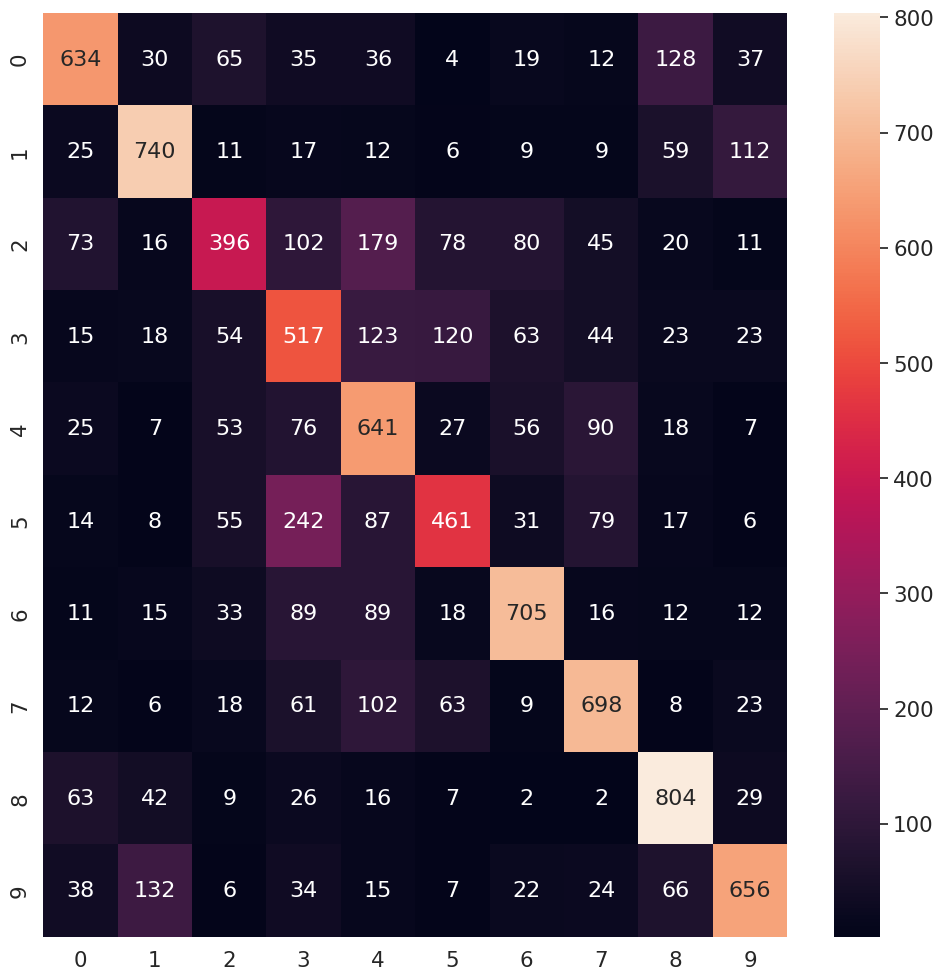

In [32]:
import seaborn as sn

plt.figure(figsize=(12, 12))
sn.set(font_scale=1.4)
sn.heatmap(conv_confusion_matrix.tolist(),
           annot=True, annot_kws={"size": 16}, fmt='d')

